<a href="https://colab.research.google.com/github/Priji123/Mtech_final_year_project/blob/main/Cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# -------------------------------------------
# STEP 1: Load + Preprocess the Dataset
# + Save X, y into Drive folder: Experiment
# -------------------------------------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Base Path
base_path = "/content/drive/MyDrive/SDNET2018"
img_size = (128, 128)

# ✅ Folder to save checkpoint files
save_folder = "/content/drive/MyDrive/Experiment"
os.makedirs(save_folder, exist_ok=True)

def load_and_preprocess_dataset(base_path, img_size=(128, 128)):
    X = []
    y = []

    # Level 1 folders (exact names)
    categories = ["Decks", "Pavement", "Walls"]

    # Level 2 folders (exact names)
    classes = ["Cracked", "Non-cracked"]  # 0 and 1 labels

    for category in categories:
        category_path = os.path.join(base_path, category)
        print(f"\n📂 Entering Category Folder: {category_path}")

        for label, cls in enumerate(classes):
            class_path = os.path.join(category_path, cls)
            print(f"   ➤ Processing Class Folder: {class_path}")

            # Check folder exists or not
            if not os.path.exists(class_path):
                print(f"   ❌ Folder not found: {class_path}")
                continue

            for filename in os.listdir(class_path):
                file_path = os.path.join(class_path, filename)

                img = cv2.imread(file_path)
                if img is None:
                    print(f"   ⚠️ Skipped corrupted file: {file_path}")
                    continue

                # Convert to grayscale
                gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

                # Resize
                resized = cv2.resize(gray, img_size)

                # Normalize
                norm = resized / 255.0

                X.append(norm)
                y.append(label)

    X = np.array(X).reshape(-1, img_size[0], img_size[1], 1)
    y = np.array(y)

    return X, y


# ✅ Load dataset
X, y = load_and_preprocess_dataset(base_path, img_size)

print("\n✅ Dataset loaded successfully")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ✅ Save X and y after Step 1 (Checkpoint)
np.save(os.path.join(save_folder, "X.npy"), X)
np.save(os.path.join(save_folder, "y.npy"), y)

print(f"\n✅ Saved X and y successfully in: {save_folder}")
print("✅ Files saved: X.npy and y.npy")



📂 Entering Category Folder: /content/drive/MyDrive/SDNET2018/Decks
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Decks/Cracked
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Decks/Non-cracked

📂 Entering Category Folder: /content/drive/MyDrive/SDNET2018/Pavement
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Pavement/Cracked
   ❌ Folder not found: /content/drive/MyDrive/SDNET2018/Pavement/Cracked
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Pavement/Non-cracked
   ❌ Folder not found: /content/drive/MyDrive/SDNET2018/Pavement/Non-cracked

📂 Entering Category Folder: /content/drive/MyDrive/SDNET2018/Walls
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Walls/Cracked
   ➤ Processing Class Folder: /content/drive/MyDrive/SDNET2018/Walls/Non-cracked

✅ Dataset loaded successfully
X shape: (31759, 128, 128, 1)
y shape: (31759,)

✅ Saved X and y successfully in: /content/drive/MyDrive/Experiment
✅ Files saved: X

✅ Loaded X and y from Drive
X shape: (31759, 128, 128, 1)
y shape: (31759,)

✅ Split completed
Training images: (25407, 128, 128, 1)
Testing images: (6352, 128, 128, 1)

✅ Saved Train/Test split successfully in: /content/drive/MyDrive/Experiment
✅ Files saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy


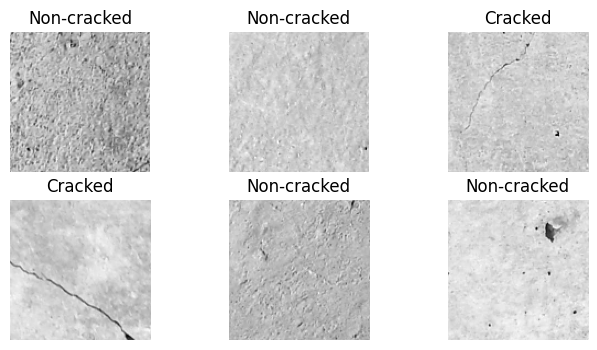

In [ ]:
# -------------------------------------------
# STEP 2: Train–Test Split + Visualization
# + Save Train/Test split into Drive folder: Experiment
# -------------------------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# ✅ Experiment folder
save_folder = "/content/drive/MyDrive/Experiment"
os.makedirs(save_folder, exist_ok=True)

# ✅ Load X and y (in case Colab restarted)
X = np.load(save_folder + "/X.npy")
y = np.load(save_folder + "/y.npy")

print("✅ Loaded X and y from Drive")
print("X shape:", X.shape)
print("y shape:", y.shape)

# ✅ Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

print("\n✅ Split completed")
print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)

# ✅ Save split arrays (Checkpoint)
np.save(os.path.join(save_folder, "X_train.npy"), X_train)
np.save(os.path.join(save_folder, "X_test.npy"), X_test)
np.save(os.path.join(save_folder, "y_train.npy"), y_train)
np.save(os.path.join(save_folder, "y_test.npy"), y_test)

print(f"\n✅ Saved Train/Test split successfully in: {save_folder}")
print("✅ Files saved: X_train.npy, X_test.npy, y_train.npy, y_test.npy")

# ✅ Visualize samples
def show_samples(X, y):
    plt.figure(figsize=(8, 4))

    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(X[i].reshape(128, 128), cmap='gray')
        plt.title("Cracked" if y[i] == 0 else "Non-cracked")
        plt.axis("off")

    plt.show()

show_samples(X_train, y_train)


In [ ]:
# -------------------------------------------
# STEP 3: Build CNN Model
# + Save model into Drive folder: Experiment
# -------------------------------------------

import os
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D,
    Flatten, Dense, Dropout, BatchNormalization
)

# ✅ Folder to save model
save_folder = "/content/drive/MyDrive/Experiment"
os.makedirs(save_folder, exist_ok=True)

# Build CNN Model
model = Sequential([

    # Convolution Block 1
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 1)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 2
    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Convolution Block 3
    Conv2D(128, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Fully Connected Layers
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')  # Binary classification
])

print("✅ CNN Model Built Successfully")

# ✅ Save initial model architecture (optional but helpful)
model_path = os.path.join(save_folder, "initial_model.h5")
model.save(model_path)

print(f"✅ Initial model saved at: {model_path}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ CNN Model Built Successfully
✅ Initial model saved at: /content/drive/MyDrive/Experiment/initial_model.h5


In [ ]:
# -------------------------------------------
# STEP 4: Compile Model
# -------------------------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,089 (12.61 MB)

 Trainable params: 3,304,641 (12.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# -------------------------------------------
# STEP 4: Compile Model
# STEP 5: Train the Model (with Auto Save)
# -------------------------------------------

import os
import numpy as np
import pickle
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# ✅ Folder to save models and history
save_folder = "/content/drive/MyDrive/Experiment"
os.makedirs(save_folder, exist_ok=True)

# ✅ Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model Compiled Successfully")

# ✅ Save BEST model automatically (based on validation accuracy)
best_model_path = os.path.join(save_folder, "best_model.h5")

checkpoint = ModelCheckpoint(
    best_model_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

# ✅ Early stopping to avoid wasting time when overfitting starts
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)


# ✅ Load train-test split from Drive (so it works after restart)
X_train = np.load(os.path.join(save_folder, "X_train.npy"))
X_test  = np.load(os.path.join(save_folder, "X_test.npy"))
y_train = np.load(os.path.join(save_folder, "y_train.npy"))
y_test  = np.load(os.path.join(save_folder, "y_test.npy"))



# ✅ Train the model
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint, early_stop]
)

print(f"\n✅ Best model saved at: {best_model_path}")

# ✅ Save training history to Drive
history_path = os.path.join(save_folder, "history.pkl")
with open(history_path, "wb") as f:
    pickle.dump(history.history, f)

print(f"✅ Training history saved at: {history_path}")


✅ Model Compiled Successfully
Epoch 1/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7759 - loss: 1.2171
Epoch 1: val_accuracy improved from -inf to 0.81911, saving model to /content/drive/MyDrive/Experiment/best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.7759 - loss: 1.2164 - val_accuracy: 0.8191 - val_loss: 0.5943
Epoch 2/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8135 - loss: 0.4811
Epoch 2: val_accuracy did not improve from 0.81911
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8135 - loss: 0.4811 - val_accuracy: 0.8191 - val_loss: 1.9027
Epoch 3/20
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8171 - loss: 0.4636
Epoch 3: val_accuracy did not improve from 0.81911
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8171 - loss: 0.4636 - val_accuracy: 0.8191 - val_loss: 0.5304
Epoch 4/20
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8234 - loss: 0.4447
Epoch 4: val_accuracy improved from 0.81911 to 0.82336, saving model to /content/drive/MyDrive/Experiment/best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.8235 - loss: 0.4446 - val_accuracy: 0.8234 - val_loss: 0.4859
Epoch 5/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8390 - loss: 0.4118
Epoch 5: val_accuracy improved from 0.82336 to 0.82557, saving model to /content/drive/MyDrive/Experiment/best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8390 - loss: 0.4118 - val_accuracy: 0.8256 - val_loss: 0.6018
Epoch 6/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8469 - loss: 0.3866
Epoch 6: val_accuracy improved from 0.82557 to 0.83092, saving model to /content/drive/MyDrive/Experiment/best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 18s 23ms/step - accuracy: 0.8469 - loss: 0.3866 - val_accuracy: 0.8309 - val_loss: 0.7317
Epoch 7/20
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8620 - loss: 0.3574
Epoch 7: val_accuracy improved from 0.83092 to 0.84698, saving model to /content/drive/MyDrive/Experiment/best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 19s 23ms/step - accuracy: 0.8620 - loss: 0.3574 - val_accuracy: 0.8470 - val_loss: 1.1349
Epoch 8/20
792/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8681 - loss: 0.3376
Epoch 8: val_accuracy did not improve from 0.84698
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.8681 - loss: 0.3376 - val_accuracy: 0.7936 - val_loss: 0.5203
Epoch 9/20
792/794 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8814 - loss: 0.3034
Epoch 9: val_accuracy did not improve from 0.84698
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.8814 - loss: 0.3034 - val_accuracy: 0.8202 - val_loss: 2.0223
Epoch 9: early stopping
Restoring model weights from the end of the best epoch: 4.

✅ Best model saved at: /content/drive/MyDrive/Experiment/best_model.h5
✅ Training history saved at: /content/drive/MyDrive/Experiment/history.pkl


In [ ]:
# -------------------------------------------
# STEP 6: Evaluate the Model (Best Model from Drive)
# -------------------------------------------

import os
from tensorflow.keras.models import load_model

# ✅ Folder where everything is saved
save_folder = "/content/drive/MyDrive/Experiment"

# ✅ Load the best saved model (recommended)
best_model_path = os.path.join(save_folder, "best_model.h5")

if os.path.exists(best_model_path):
    model = load_model(best_model_path)
    print(f"✅ Loaded best model from: {best_model_path}")
else:
    print("⚠️ best_model.h5 not found. Using current model in memory...")

# ✅ Evaluate
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n✅ Test Evaluation Completed")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)



✅ Loaded best model from: /content/drive/MyDrive/Experiment/best_model.h5
199/199 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8503 - loss: 1.1079

✅ Test Evaluation Completed
Test Loss: 1.1349257230758667
Test Accuracy: 0.8469773530960083


✅ Using history from current session


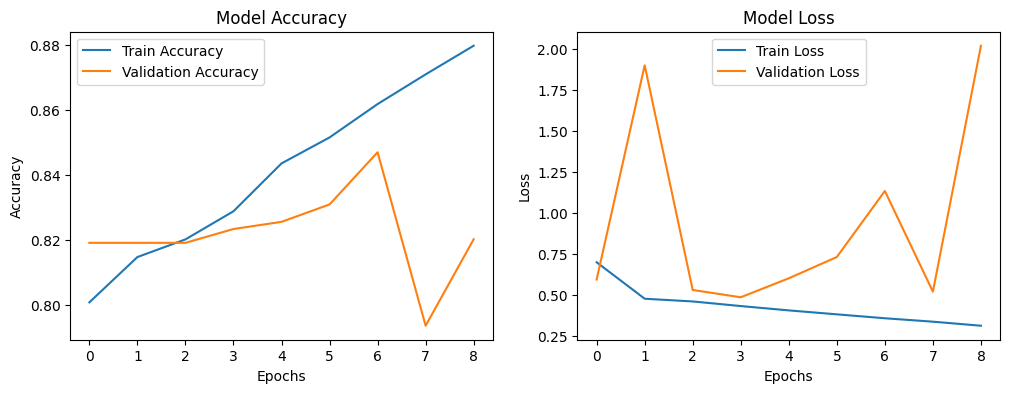

In [ ]:
# -------------------------------------------
# STEP 7: Plot Accuracy & Loss Curves
# (Works even if Colab disconnected)
# -------------------------------------------

import os
import pickle
import matplotlib.pyplot as plt

save_folder = "/content/drive/MyDrive/Experiment"
history_path = os.path.join(save_folder, "history.pkl")

# ✅ If history is not available in RAM, load it from Drive
if "history" in globals():
    hist = history.history
    print("✅ Using history from current session")
else:
    if os.path.exists(history_path):
        with open(history_path, "rb") as f:
            hist = pickle.load(f)
        print(f"✅ Loaded history from Drive: {history_path}")
    else:
        raise FileNotFoundError("❌ history.pkl not found. Train the model first!")

# ✅ Plot
plt.figure(figsize=(12, 4))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='Train Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='Train Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.show()



In [ ]:
# -------------------------------------------
# STEP 8: Save the Trained Model (Drive Safe Save)
# -------------------------------------------

import os

save_folder = "/content/drive/MyDrive/Experiment"
os.makedirs(save_folder, exist_ok=True)

model_path = os.path.join(save_folder, "crack_detection_cnn.h5")

model.save(model_path)
print("✅ Model saved successfully!")
print("📌 Saved at:", model_path)


✅ Model saved successfully!
📌 Saved at: /content/drive/MyDrive/Experiment/crack_detection_cnn.h5
